In [1]:
from datetime import datetime

In [2]:
import arcgis
from arcgis.gis import GIS

gis = GIS("https://pythonapi.playground.esri.com/portal", "arcgis_python", "amazing_arcgis_123")
gis

GIS @ https://pythonapi.playground.esri.com/portal version:7.1

In [3]:
arcgis.env.verbose=True

In [4]:
roads=gis.content.search("title:roads", item_type="Feature Layer Collection")[0].layers[0]
roads

<FeatureLayer url:"https://pythonapi.playground.esri.com/server/rest/services/Hosted/roads/FeatureServer/0">

In [5]:
sf_custs_shp=gis.content.search("title:sf_custs_shp", item_type="Feature Layer Collection")[0].layers[0]
sf_custs_shp

<FeatureLayer url:"https://pythonapi.playground.esri.com/server/rest/services/Hosted/sf_custs_shp/FeatureServer/0">

In [6]:
schr_poly=gis.content.search("title:schr_poly", item_type="Feature Layer Collection")[0].layers[0]
schr_poly

<FeatureLayer url:"https://pythonapi.playground.esri.com/server/rest/services/Hosted/schr_poly/FeatureServer/0">

Convert point features to raster

Submitted.
Executing...
ConvertFeatureToRaster GP Job: j8e4a71e0600141bb998ff551e905e6cc finished successfully.


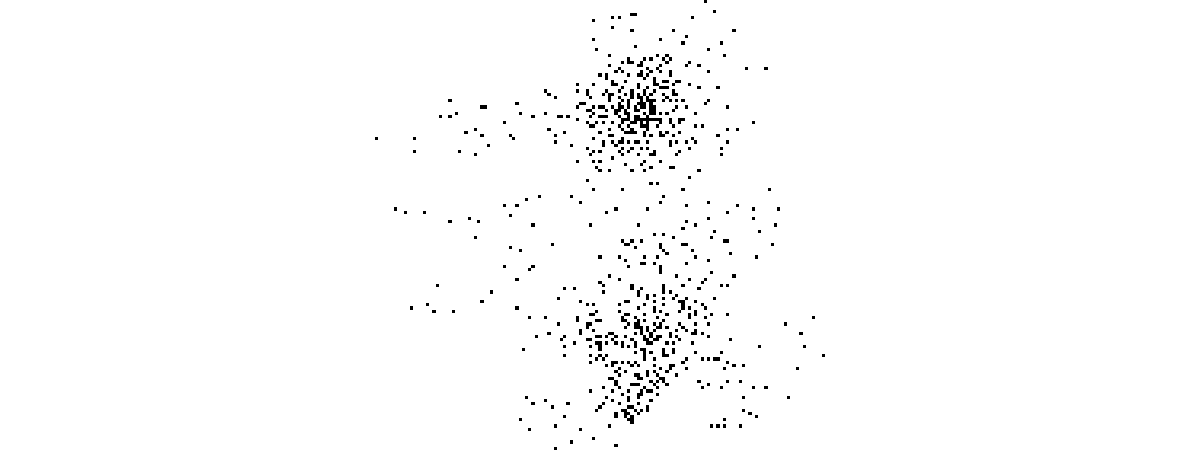

In [7]:
convert_feature_to_raster_1 = arcgis.raster.analytics.convert_feature_to_raster(input_feature=sf_custs_shp,
                                                                                output_cell_size={"distance":100,"units":"meters"}, 
                                                                                value_field="SALES",
                                                                                gis=gis)
convert_feature_to_raster_1.layers[0]

Convert point features to raster with environment variable analysis_extent set

In [8]:
sf_custs_shp_aoi = {"xmin": -13633946.5247196, "ymin": 4544946.0757069, "xmax": -13624287.111718, "ymax": 4552826.60826073, "spatialReference": {"wkid": 3857}}

ConvertFeatureToRaster GP Job: j0bebb94eb45c480ea32161d836f65751 finished successfully.


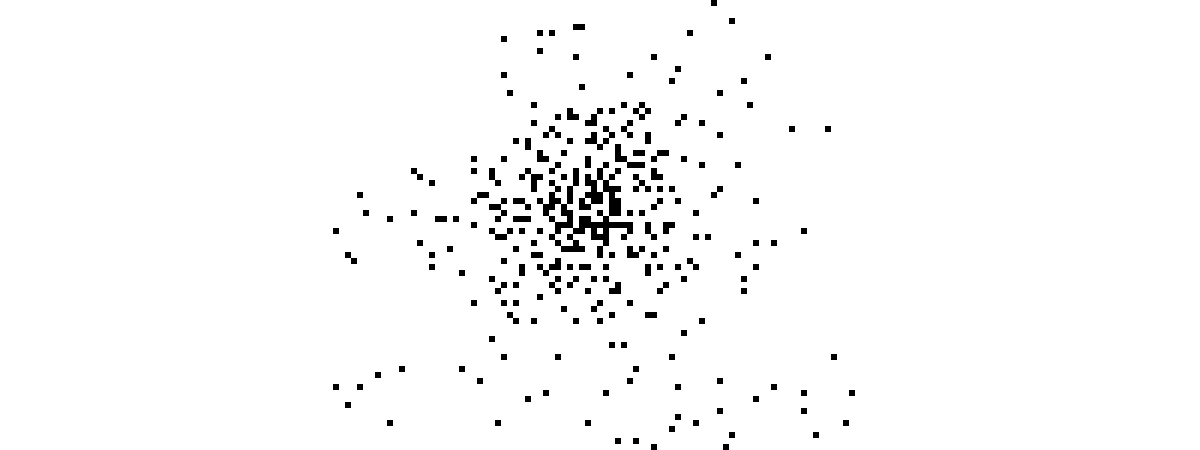

In [9]:
arcgis.env.analysis_extent = sf_custs_shp_aoi
convert_feature_to_raster_2 = arcgis.raster.analytics.convert_feature_to_raster(input_feature=sf_custs_shp,
                                                                                output_cell_size={"distance":100,"units":"meters"}, 
                                                                                value_field="SALES",
                                                                                output_name="convert_feature_to_raster_" +str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                                                future=True,
                                                                                gis=gis)
convert_feature_to_raster_2.result().layers[0]

In [10]:
arcgis.env.analysis_extent = None

Convert Polygon Features to Raster

In [11]:
convert_feature_to_raster_3 = arcgis.raster.analytics.convert_feature_to_raster(input_feature=schr_poly,
                                                                                output_cell_size={"distance":5,"units":"Kilometers"},
                                                                                value_field="GRIDCODE",
                                                                                output_name="convert_feature_to_raster_" +str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                                                context=None,
                                                                                future=True,
                                                                                gis=gis)
convert_feature_to_raster_3.result()

Submitted.
Executing...
ConvertFeatureToRaster GP Job: jae4b4c5a9bb14157bb5000f9fbdc0522 finished successfully.


<Item title:"convert_feature_to_raster_20191010202137" type:Imagery Layer owner:arcgis_python>

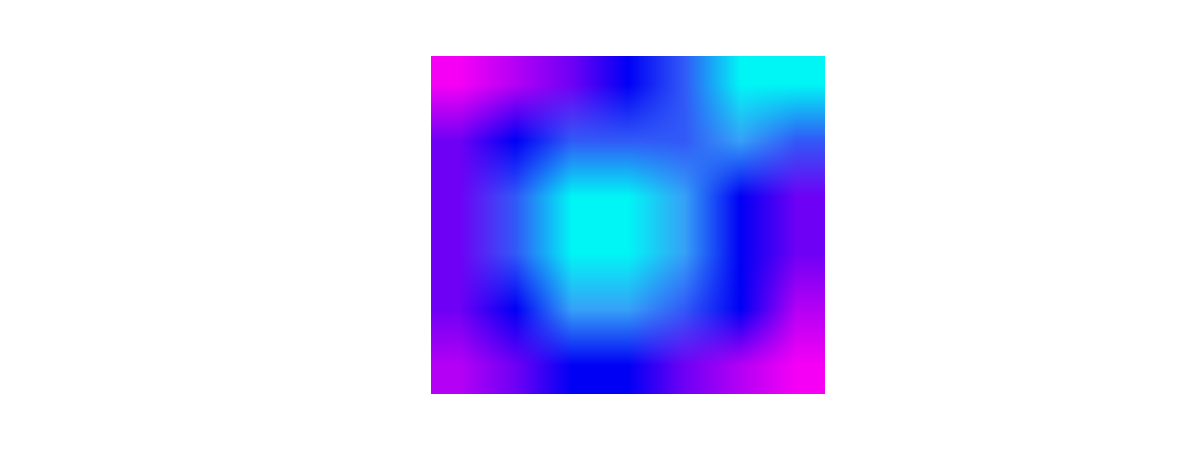

In [12]:
arcgis.raster.functions.colormap(arcgis.raster.functions.stretch(convert_feature_to_raster_3.result().layers[0],stretch_type=5,min=0,max=255), colorramp="Cyan to Purple")

Convert Line Features to Raster

In [13]:
roads_aoi = {"xmin": 476173.442408594, "ymin": 215156.780899781, "xmax": 482264.946024594, "ymax": 222247.671827781, "spatialReference": {"wkid": 32145}}

Submitted.
Executing...
ConvertFeatureToRaster GP Job: j84300d0e4e814dedaa3037db6fe5634b finished successfully.


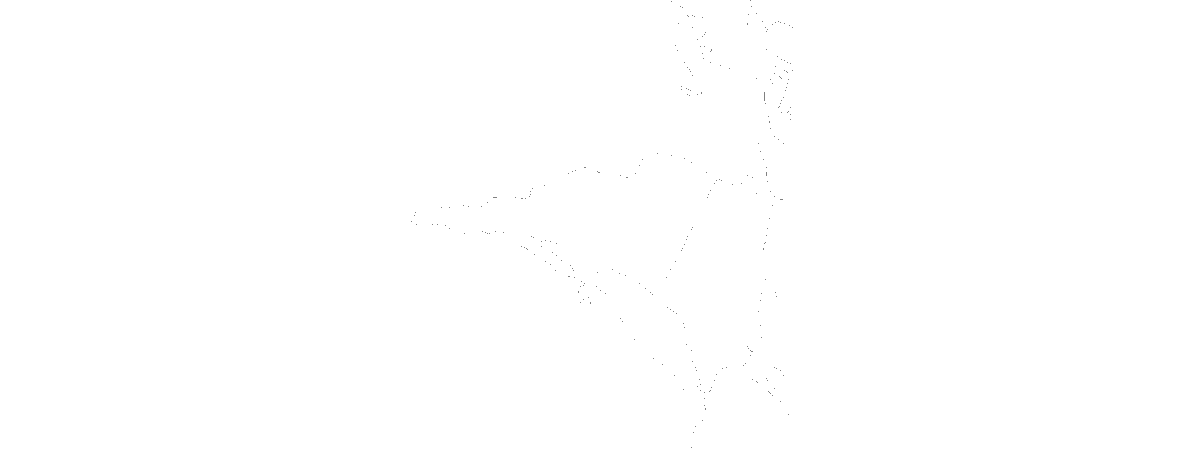

In [14]:
convert_feature_to_raster_4 = arcgis.raster.analytics.convert_feature_to_raster(input_feature=roads,
                                                                                output_cell_size={"distance":10,"units":"Feet"}, 
                                                                                value_field="street_nam",
                                                                                output_name="convert_feature_to_raster_" +str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                                                context={"extent":roads_aoi},
                                                                                future=True,
                                                                                gis=gis)
convert_feature_to_raster_4.result().layers[0]

<h4> Clean Up

In [15]:
convert_feature_to_raster_1.delete()

True

In [16]:
convert_feature_to_raster_2.result().delete()

True

In [17]:
convert_feature_to_raster_3.result().delete()

True

In [18]:
convert_feature_to_raster_4.result().delete()

True